# Gradient fitting & profile likelihood (Data2Dynamics-style)

This notebook runs the **Data2Dynamics (D2D) parameter-estimation workflow**
(Raue, Schilling, Timmer et al.) end-to-end with **bngsim**:

1. **Multi-start** local optimization — many random starts to escape local minima.
2. **Trust-region reflective** bounded least-squares
   (`scipy.optimize.least_squares(method="trf")`), a Gauss–Newton / Levenberg–Marquardt
   method that consumes the **residual vector and its Jacobian** directly. The Jacobian
   is built from **bngsim's CVODES forward sensitivities** — no finite differences.
3. **Profile likelihood** — one re-optimization sweep per parameter, for identifiability
   and confidence intervals (the D2D-preferred uncertainty method).

Fitting is done in **`log10` parameter space**, as in D2D.

### Model & data — licensing-clean by construction

The model is the **Becker et al. (2010) erythropoietin-receptor (EpoR) core model**,
[`becker_epo_receptor.ant`](becker_epo_receptor.ant) — BioModels
[`BIOMD0000000271`](https://www.ebi.ac.uk/biomodels/BIOMD0000000271), released under
**CC0** (public domain). The data here is **synthetic**: simulated from that model at
its own published parameters plus seeded Gaussian noise. So this is a clean *recovery*
demonstration — the true answer is known — with **no third-party experimental data**.

> References: V. Becker et al., *Science* 328:1404 (2010) — the model; A. Raue et al.,
> *Bioinformatics* 31:3558 (2015) — the D2D method.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl; mpl.rcParams["figure.dpi"] = 90
from scipy.optimize import least_squares

import bngsim
print("bngsim", bngsim.__version__)

bngsim 0.9.67


## The model and its observables

The EpoR model has six species. Epo binds its receptor (`kon`/`koff`), the complex is
internalized (`ke`), then recycled (`kex`) or degraded intra-/extra-cellularly
(`kdi`/`kde`); receptor turns over at `kt`. Becker measured three quantities, which we
reconstruct from the species trajectories:

- **extracellular** Epo = `Epo + dEpoe`
- **membrane-bound** complex = `Epo_EpoR`
- **internalized** Epo = `Epo_EpoRi + dEpoi`

We fit the **seven kinetic rate constants** in `log10` space. bngsim provides the ODE
solution *and* the forward sensitivities `d(species)/d(parameter)` in one solve.

In [2]:
MODEL = Path.cwd() / "becker_epo_receptor.ant"
model = bngsim.Model.from_antimony(str(MODEL))
sp = {name: i for i, name in enumerate(model.species_names)}
print("species:", model.species_names)

# Published (truth) kinetic rate constants -- read straight from the CC0 model.
TRUTH = dict(kt=0.0329366, kon=0.00010496, koff=0.0172135,
             ke=0.0748267, kex=0.00993805, kdi=0.00317871, kde=0.0164042)
FIT = list(TRUTH)
LN10 = np.log(10.0)

# Two ODE simulators: one carrying forward sensitivities (for the Jacobian), one plain.
sim_sens = bngsim.Simulator(model, method="ode", sensitivity_params=FIT)
sim_plain = bngsim.Simulator(model, method="ode")
T0, T1, NGRID = 0.0, 300.0, 601

OBS_NAMES = ["Epo_extracellular", "Epo_membrane", "Epo_internalized"]
NOBS = len(OBS_NAMES)

def observables(Y):
    return np.column_stack([
        Y[:, sp["Epo"]] + Y[:, sp["dEpoe"]],        # extracellular
        Y[:, sp["Epo_EpoR"]],                        # membrane-bound complex
        Y[:, sp["Epo_EpoRi"]] + Y[:, sp["dEpoi"]],   # internalized
    ])

def simulate(theta, with_sens=False):
    '''Simulate at parameters 10**theta; return (t, observables[, d(obs)/d(param)]).'''
    model.set_params({n: 10.0 ** theta[i] for i, n in enumerate(FIT)})
    model.reset()
    out = (sim_sens if with_sens else sim_plain).run(t_span=(T0, T1), n_points=NGRID)
    t = np.asarray(out.time, float)
    obs = observables(np.asarray(out.species, float))
    if not with_sens:
        return t, obs, None
    S = np.asarray(out.sensitivities, float)         # (n_t, n_species, n_fit)
    obs_sens = np.stack([
        S[:, sp["Epo"], :] + S[:, sp["dEpoe"], :],
        S[:, sp["Epo_EpoR"], :],
        S[:, sp["Epo_EpoRi"], :] + S[:, sp["dEpoi"], :],
    ], axis=1)                                        # (n_t, NOBS, n_fit)
    return t, obs, obs_sens

theta_true = np.array([np.log10(TRUTH[n]) for n in FIT])
LB, UB = theta_true - 1.0, theta_true + 1.0          # search box: +/- 1 decade around truth
print("fitting", len(FIT), "parameters:", FIT)

species: ['EpoR', 'Epo', 'Epo_EpoR', 'Epo_EpoRi', 'dEpoi', 'dEpoe']
fitting 7 parameters: ['kt', 'kon', 'koff', 'ke', 'kex', 'kdi', 'kde']


## Synthesize the data

Simulate at the published truth, sample at a set of measurement times, and add seeded
Gaussian noise (σ = 3 % of each observable's scale). Because the data comes from the
model, a correct fit will recover the truth.

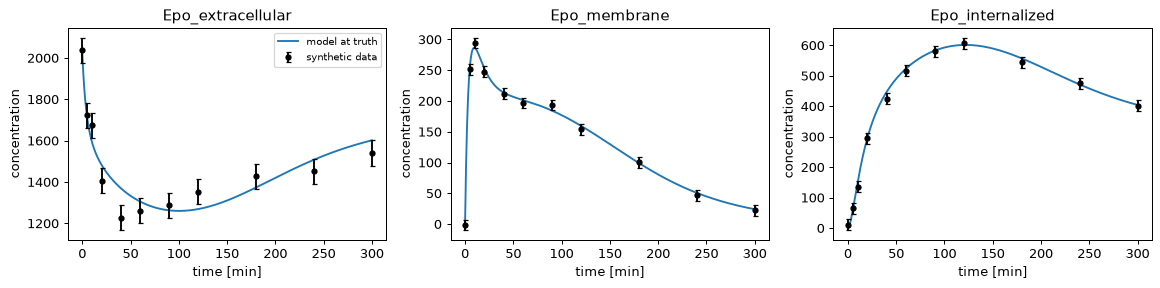

In [3]:
DATA_T = np.array([0, 5, 10, 20, 40, 60, 90, 120, 180, 240, 300], float)

t_g, obs_g, _ = simulate(theta_true)
truth_at_data = np.column_stack([np.interp(DATA_T, t_g, obs_g[:, j]) for j in range(NOBS)])
SIGMA = np.array([0.03 * obs_g[:, c].max() for c in range(NOBS)])   # constant per observable
rng = np.random.default_rng(0)
DATA = truth_at_data + rng.normal(0.0, 1.0, truth_at_data.shape) * SIGMA[None, :]

fig, axes = plt.subplots(1, NOBS, figsize=(13, 3.3))
for j, ax in enumerate(axes):
    ax.plot(t_g, obs_g[:, j], color="C0", lw=1.5, label="model at truth")
    ax.errorbar(DATA_T, DATA[:, j], yerr=SIGMA[j], fmt="o", color="k", ms=4,
                capsize=2, label="synthetic data")
    ax.set_title(OBS_NAMES[j]); ax.set_xlabel("time [min]"); ax.set_ylabel("concentration")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Objective: weighted residuals + analytic Jacobian

The residual for each observed point is `(model − data) / σ`. Because we fit in `log10`
space, the chain rule turns bngsim's `d(obs)/d(param)` sensitivity into the column we
need:

$$\frac{\partial r_i}{\partial\,\log_{10}\theta_j}
   = \frac{1}{\sigma_i}\,\frac{\partial\,\mathrm{obs}_i}{\partial\theta_j}\;\theta_j\,\ln 10 .$$

We verify the analytic Jacobian against a finite difference — it should match to solver
tolerance.

In [4]:
def residual_only(theta):
    t, obs, _ = simulate(theta, with_sens=False)
    y = np.column_stack([np.interp(DATA_T, t, obs[:, j]) for j in range(NOBS)])
    return ((y - DATA) / SIGMA[None, :]).ravel()

def residual_and_jac(theta):
    t, obs, obs_sens = simulate(theta, with_sens=True)
    y = np.column_stack([np.interp(DATA_T, t, obs[:, j]) for j in range(NOBS)])
    r = ((y - DATA) / SIGMA[None, :]).ravel()
    param = 10.0 ** theta
    J = np.empty((DATA.size, len(FIT)))
    for j in range(len(FIT)):
        dobs = np.column_stack([np.interp(DATA_T, t, obs_sens[:, c, j]) for c in range(NOBS)])
        J[:, j] = ((dobs / SIGMA[None, :]) * param[j] * LN10).ravel()
    return r, J

def cached_r_and_j():
    '''Memoize the last theta so least_squares' fun and jac share one simulation.'''
    store = {}
    def f(theta):
        key = theta.tobytes()
        if key not in store:
            store.clear(); store[key] = residual_and_jac(theta)
        return store[key]
    return f

# Finite-difference check of the analytic Jacobian (ke column) at the truth.
r0, J0 = residual_and_jac(theta_true)
h = 1e-5; jc = FIT.index("ke"); e = np.zeros_like(theta_true); e[jc] = h
J_fd = (residual_only(theta_true + e) - residual_only(theta_true - e)) / (2 * h)
print("chi2 at truth:", float(np.sum(r0 ** 2)), " (", DATA.size, "residuals )")
print("max |J_analytic - J_finite_diff| (ke column):", float(np.max(np.abs(J0[:, jc] - J_fd))))

chi2 at truth: 21.174562197337384  ( 33 residuals )
max |J_analytic - J_finite_diff| (ke column): 5.387709910209537e-06


## Multi-start trust-region optimization

Each start draws a random `log10` point in the ±1-decade box and runs bounded TRF. We
keep the lowest-χ² fit. The **waterfall plot** (sorted final χ²) shows how many starts
reached the best basin.

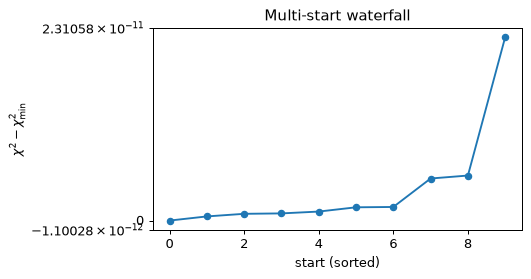

best chi2 = 20.47  (33 residuals, 7 params)

param         truth    recovered   rel err
kt        0.0329366    0.0329851     0.1%
kon      0.00010496  0.000101583     3.2%
koff      0.0172135    0.0126764    26.4%
ke        0.0748267    0.0753286     0.7%
kex      0.00993805     0.010234     3.0%
kdi      0.00317871   0.00345358     8.6%
kde       0.0164042    0.0170676     4.0%


In [5]:
N_STARTS = 10
starts_rng = np.random.default_rng(7)

results = []
for s in range(N_STARTS):
    x0 = starts_rng.uniform(LB, UB)
    rj = cached_r_and_j()
    res = least_squares(lambda x: rj(x)[0], x0, jac=lambda x: rj(x)[1],
                        bounds=(LB, UB), method="trf", x_scale="jac",
                        ftol=1e-10, xtol=1e-10, gtol=1e-10, max_nfev=400)
    results.append(res)

chi2_final = np.array([2.0 * r.cost for r in results])
best = results[int(np.argmin(chi2_final))]
theta_hat = best.x
chi2_min = float(2.0 * best.cost)

order = np.argsort(chi2_final)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.arange(N_STARTS), chi2_final[order] - chi2_min, "o-", ms=5)
ax.set_xlabel("start (sorted)"); ax.set_ylabel(r"$\chi^2 - \chi^2_{\min}$")
ax.set_title("Multi-start waterfall"); ax.set_yscale("symlog", linthresh=1e-3)
plt.tight_layout(); plt.show()

print(f"best chi2 = {chi2_min:.2f}  ({DATA.size} residuals, {len(FIT)} params)\n")
print(f"{'param':6s} {'truth':>12s} {'recovered':>12s} {'rel err':>9s}")
for i, n in enumerate(FIT):
    tr, rc = TRUTH[n], 10.0 ** theta_hat[i]
    print(f"{n:6s} {tr:12.6g} {rc:12.6g} {abs(rc-tr)/tr:8.1%}")

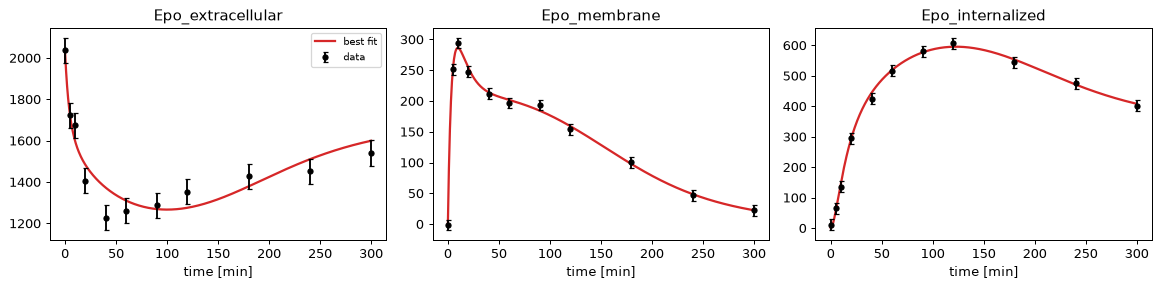

In [6]:
# Best fit vs data.
t_b, obs_b, _ = simulate(theta_hat)
fig, axes = plt.subplots(1, NOBS, figsize=(13, 3.3))
for j, ax in enumerate(axes):
    ax.plot(t_b, obs_b[:, j], color="C3", lw=1.8, label="best fit")
    ax.errorbar(DATA_T, DATA[:, j], yerr=SIGMA[j], fmt="o", color="k", ms=4,
                capsize=2, label="data")
    ax.set_title(OBS_NAMES[j]); ax.set_xlabel("time [min]")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## Profile likelihood

For each parameter we fix it across a grid and re-optimize all the others, tracing the
profile $\chi^2$. Where the profile rises past $\Delta\chi^2 = 3.84$ (the 95 %, 1-dof
threshold) sets the confidence interval. A **steep** profile → well identified; a
**flat** one → practically non-identifiable.

In [7]:
def profile(fixed_i, npts=17, half=0.7):
    grid = np.unique(np.clip(np.linspace(theta_hat[fixed_i] - half, theta_hat[fixed_i] + half, npts),
                             LB[fixed_i], UB[fixed_i]))
    free = [i for i in range(len(FIT)) if i != fixed_i]
    costs = np.full(grid.size, np.nan)
    center = int(np.argmin(np.abs(grid - theta_hat[fixed_i])))

    def opt_at(k, start):
        rj = cached_r_and_j()
        def fun(xf):
            th = theta_hat.copy(); th[fixed_i] = grid[k]; th[free] = xf; return rj(th)[0]
        def jac(xf):
            th = theta_hat.copy(); th[fixed_i] = grid[k]; th[free] = xf; return rj(th)[1][:, free]
        r = least_squares(fun, start, jac=jac, bounds=(LB[free], UB[free]),
                          method="trf", x_scale="jac", max_nfev=300)
        costs[k] = 2.0 * r.cost
        return np.asarray(r.x)

    w = opt_at(center, theta_hat[free]); anchor = w.copy()
    for k in range(center + 1, grid.size): w = opt_at(k, w)
    w = anchor.copy()
    for k in range(center - 1, -1, -1): w = opt_at(k, w)
    return grid, costs

def ci_from_profile(grid, costs, thr=3.84):
    d = costs - chi2_min; kmin = int(np.argmin(d)); lo = hi = None
    for k in range(kmin, 0, -1):
        if d[k - 1] >= thr:
            f = (thr - d[k]) / (d[k - 1] - d[k]); lo = grid[k] + f * (grid[k - 1] - grid[k]); break
    for k in range(kmin, grid.size - 1):
        if d[k + 1] >= thr:
            f = (thr - d[k]) / (d[k + 1] - d[k]); hi = grid[k] + f * (grid[k + 1] - grid[k]); break
    return lo, hi

profiles = {n: profile(FIT.index(n)) for n in FIT}
print("profiles computed for", list(profiles))

profiles computed for ['kt', 'kon', 'koff', 'ke', 'kex', 'kdi', 'kde']


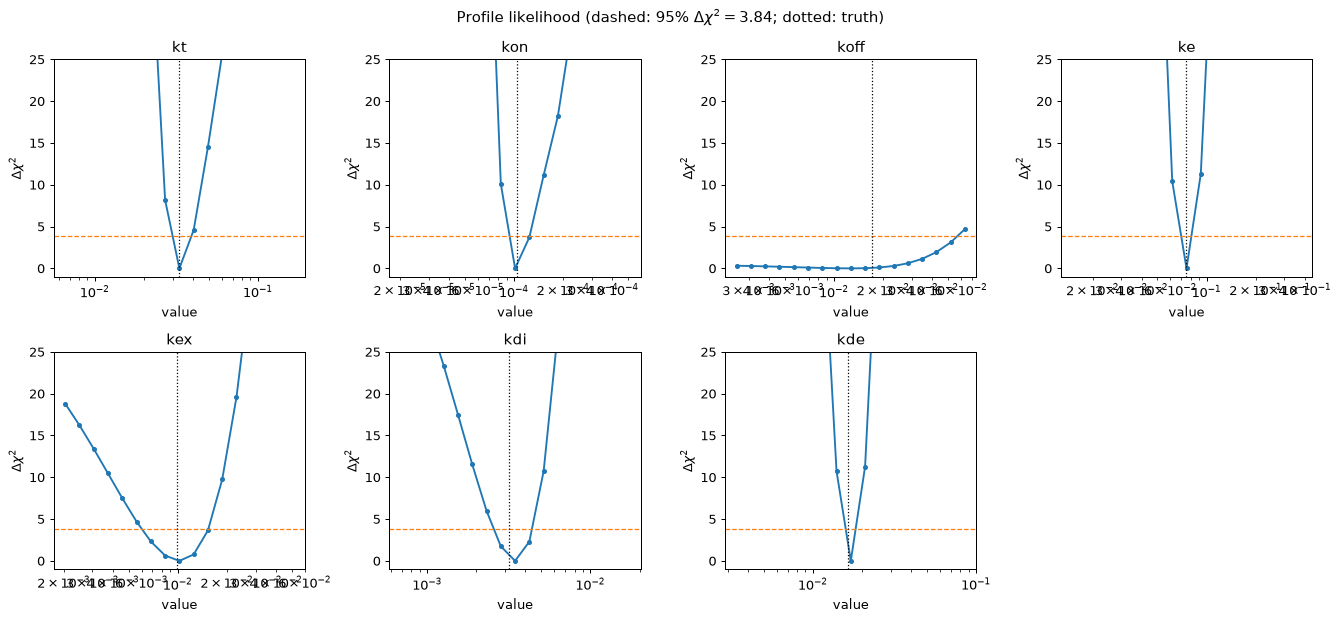

param        truth    estimate  95% CI low 95% CI high  identifiable
kt        0.032937    0.032985     0.03001     0.03906  yes
kon     0.00010496  0.00010158    9.41e-05   0.0001247  yes
koff      0.017213    0.012676        ----     0.05693  NO (open profile)
ke        0.074827    0.075329     0.06994     0.08066  yes
kex      0.0099381    0.010234    0.006015     0.01541  yes
kdi      0.0031787   0.0034536    0.002557    0.004382  yes
kde       0.016404    0.017068     0.01588     0.01828  yes


In [8]:
THR = 3.84
fig, axes = plt.subplots(2, 4, figsize=(15, 7)); axes = axes.ravel()
rows = []
for ax, n in zip(axes, FIT):
    grid, costs = profiles[n]; d = costs - chi2_min
    lo, hi = ci_from_profile(grid, costs)
    ax.plot(10.0 ** grid, d, "o-", ms=3)
    ax.axhline(THR, color="C1", ls="--", lw=1)
    ax.axvline(TRUTH[n], color="k", ls=":", lw=1)
    ax.set_xscale("log"); ax.set_title(n); ax.set_ylim(-1, 25)
    ax.set_xlabel("value"); ax.set_ylabel(r"$\Delta\chi^2$")
    lo_v = 10.0 ** lo if lo is not None else None
    hi_v = 10.0 ** hi if hi is not None else None
    brackets = (lo_v is not None and hi_v is not None and lo_v <= TRUTH[n] <= hi_v)
    rows.append((n, TRUTH[n], 10.0 ** theta_hat[FIT.index(n)], lo_v, hi_v, brackets))
for ax in axes[len(FIT):]: ax.axis("off")
fig.suptitle(r"Profile likelihood (dashed: 95% $\Delta\chi^2=3.84$; dotted: truth)")
plt.tight_layout(); plt.show()

def fmt(x): return "----" if x is None else f"{x:.4g}"
print(f"{'param':6s} {'truth':>11s} {'estimate':>11s} {'95% CI low':>11s} {'95% CI high':>11s}  identifiable")
for n, tr, est, lo, hi, brk in rows:
    tag = "yes" if (lo is not None and hi is not None) else "NO (open profile)"
    print(f"{n:6s} {tr:11.5g} {est:11.5g} {fmt(lo):>11s} {fmt(hi):>11s}  {tag}")

## Takeaways

- **Multi-start TRF with an analytic Jacobian** from bngsim forward sensitivities recovers
  the kinetic rates — the gradient-based counterpart to PyBNF's metaheuristic fits
  (issues #385/#386). The Jacobian is exact (it matched finite differences above), so TRF
  converges in few iterations.
- **Profile likelihood is the identifiability diagnostic.** Most rates give steep profiles
  with tight CIs that bracket the truth; **`koff` is only weakly identified** from these
  observables — its profile is flat/one-sided, so its lower CI is open. A point estimate
  alone would hide that; the profile makes it explicit. This is exactly the D2D uncertainty
  workflow.
- The whole example is **licensing-clean**: a CC0 BioModels model plus data *simulated from
  it*. To fit the model to **real** Becker data you would supply that data yourself under
  its own terms — the workflow code above is unchanged.
- For a scheduler-driven version of gradient fitting and profiles, see PyBNF's
  `job_type = trf` / `lbfgs` (tutorial lesson 01) and `job_type = profile_likelihood`.